<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/Pytorch_SeismicActivity_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/08-seismic_activity_svm.csv')

In [27]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [28]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [30]:
df.seismic_event_detected.unique()

array([0, 1])

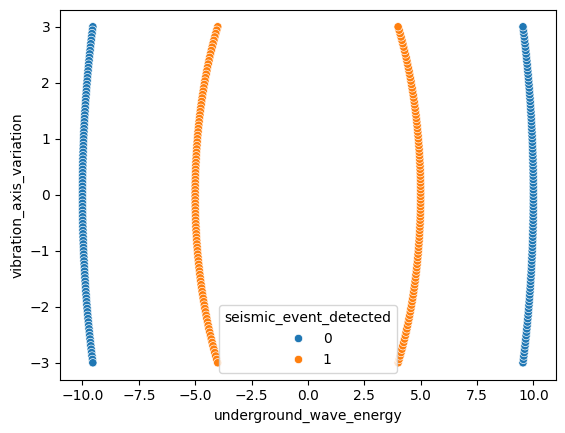

In [31]:
sns.scatterplot(x=df['underground_wave_energy'],y=df['vibration_axis_variation'],hue=df['seismic_event_detected'])
plt.show()

In [32]:
X = df[['underground_wave_energy','vibration_axis_variation']].values
y = df['seismic_event_detected'].values

In [33]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [36]:
len(X_train),len(X_test),len(y_train),len(y_test)

(320, 80, 320, 80)

In [37]:
X_train = torch.tensor(X_train , dtype=torch.float32)
X_test = torch.tensor(X_test , dtype=torch.float32)

y_train = torch.tensor(y_train , dtype = torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test , dtype = torch.float32).unsqueeze(1)

In [38]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [40]:
y_train.ndim

2

In [41]:
from torch import nn

In [51]:
class ClassificationModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(in_features=2,out_features=5)
    self.layer2 = nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer2(self.layer1(x))

In [52]:
model_0 = ClassificationModel()

In [53]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [54]:
def calculate_score(y_test,y_pred):
  correct = torch.eq(y_test,y_pred).sum().item()
  accuracy = correct / len(y_pred) * 100
  return accuracy

In [55]:
y_logits = model_0(X_test)[:5]
y_logits

tensor([[ 0.3003],
        [-0.7717],
        [-0.3469],
        [-0.9264],
        [ 0.6094]], grad_fn=<SliceBackward0>)

In [57]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5745],
        [0.3161],
        [0.4141],
        [0.2837],
        [0.6478]], grad_fn=<SigmoidBackward0>)

In [58]:
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [0.],
        [0.],
        [0.],
        [1.]], grad_fn=<RoundBackward0>)

In [59]:
y_test[:5]

tensor([[1.],
        [0.],
        [1.],
        [0.],
        [0.]])

In [61]:
calculate_score(y_test[:5],y_preds)

60.0

In [64]:
torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
  model_0.train()

  y_logits = model_0(X_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)
  acc = calculate_score(y_test=y_train,y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()

  with torch.inference_mode():
    test_logits = model_0(X_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,y_test)
    test_acc = calculate_score(y_test=y_test,y_pred = test_pred)

    if epoch % 5 == 0 :
      print(f"Epoch : {epoch}, Loss : {loss} , Accuracy : {acc} , Test Loss : {test_loss} , Test Accuracy : {test_acc}")

Epoch : 0, Loss : 0.7289450168609619 , Accuracy : 50.625 , Test Loss : 0.7329809069633484 , Test Accuracy : 47.5
Epoch : 5, Loss : 0.706088125705719 , Accuracy : 48.125 , Test Loss : 0.7135168313980103 , Test Accuracy : 41.25
Epoch : 10, Loss : 0.6976238489151001 , Accuracy : 44.0625 , Test Loss : 0.7055932283401489 , Test Accuracy : 36.25
Epoch : 15, Loss : 0.6945241689682007 , Accuracy : 42.5 , Test Loss : 0.7022584676742554 , Test Accuracy : 42.5
Epoch : 20, Loss : 0.6933779716491699 , Accuracy : 46.25 , Test Loss : 0.7007887959480286 , Test Accuracy : 47.5
Epoch : 25, Loss : 0.6929373741149902 , Accuracy : 49.375 , Test Loss : 0.7001132965087891 , Test Accuracy : 50.0
Epoch : 30, Loss : 0.6927517652511597 , Accuracy : 50.0 , Test Loss : 0.6997974514961243 , Test Accuracy : 51.24999999999999
Epoch : 35, Loss : 0.6926590800285339 , Accuracy : 50.0 , Test Loss : 0.699656069278717 , Test Accuracy : 51.24999999999999
Epoch : 40, Loss : 0.6926011443138123 , Accuracy : 49.6875 , Test Loss